In [1]:
# ============================================================
# NOTEBOOK 3
# ROBUST LINEAR SVM WITH WORD + CHARACTER TF-IDF
# ============================================================

import json
import time
import joblib
import warnings

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

from sklearn.model_selection import (
    GridSearchCV,
    PredefinedSplit
)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("=" * 70)
print("ROBUST WORD + CHARACTER LINEAR SVM")
print("=" * 70)

ROBUST WORD + CHARACTER LINEAR SVM


In [2]:
# ============================================================
# STEP 2 - PATHS
# ============================================================

BASE_DIR = (
    Path.home()
    / "Desktop"
    / "Classification_Model"
)

DATA_FILE = (
    BASE_DIR
    / "Expense_Messages_Dataset_Robust_8400.csv"
)

TRAIN_FILE = (
    BASE_DIR
    / "splits"
    / "train_split.csv"
)

VAL_FILE = (
    BASE_DIR
    / "splits"
    / "validation_split.csv"
)

TEST_FILE = (
    BASE_DIR
    / "splits"
    / "test_split.csv"
)

OLD_MODEL_PATH = (
    BASE_DIR
    / "optimized_models"
    / "optimized_linear_svm.joblib"
)

ROBUST_MODEL_DIR = (
    BASE_DIR
    / "robust_models"
)

ROBUST_REPORT_DIR = (
    BASE_DIR
    / "robust_reports"
)

ROBUST_FIGURE_DIR = (
    BASE_DIR
    / "robust_figures"
)

ROBUST_MODEL_DIR.mkdir(exist_ok=True)
ROBUST_REPORT_DIR.mkdir(exist_ok=True)
ROBUST_FIGURE_DIR.mkdir(exist_ok=True)

print("Dataset:", DATA_FILE.exists())
print("Train:", TRAIN_FILE.exists())
print("Validation:", VAL_FILE.exists())
print("Test:", TEST_FILE.exists())
print("Old model:", OLD_MODEL_PATH.exists())

Dataset: True
Train: True
Validation: True
Test: True
Old model: True


In [3]:
# ============================================================
# STEP 3 - LOAD EXISTING ROBUST 8400 SPLITS
# ============================================================

train_df = pd.read_csv(TRAIN_FILE)
val_df = pd.read_csv(VAL_FILE)
test_df = pd.read_csv(TEST_FILE)

print("=" * 70)
print("ROBUST SPLITS LOADED")
print("=" * 70)

print("\nTrain:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

print("\nTrain class distribution:")
print(
    train_df["Category"]
    .value_counts()
    .sort_index()
)

ROBUST SPLITS LOADED

Train: 5880
Validation: 1260
Test: 1260

Train class distribution:
Category
Bills            420
Business         420
Education        420
Entertainment    420
Food             420
Gift             420
Health           420
Investment       420
OTP_REJECT       420
Others           420
Salary           420
Shopping         420
Transport        420
Travel           420
Name: count, dtype: int64


In [4]:
# ============================================================
# STEP 4 - VERIFY CLEAN_SMS
# ============================================================

for name, split_df in {
    "Train": train_df,
    "Validation": val_df,
    "Test": test_df
}.items():

    if "Clean_SMS" not in split_df.columns:

        raise ValueError(
            f"{name} split does not contain Clean_SMS"
        )

print("=" * 70)
print("CLEAN_SMS VERIFIED")
print("=" * 70)

print("\nSample:")
print(train_df["Clean_SMS"].iloc[0])

CLEAN_SMS VERIFIED

Sample:
purchase <AMOUNT> railway ride fare


In [5]:
# ============================================================
# STEP 5 - LOAD OLD OPTIMIZED LINEAR SVM
# ============================================================

old_model = joblib.load(
    OLD_MODEL_PATH
)

print("=" * 70)
print("OLD OPTIMIZED SVM LOADED")
print("=" * 70)

print(old_model)

OLD OPTIMIZED SVM LOADED
Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=20000, strip_accents='unicode',
                                 sublinear_tf=True)),
                ('classifier',
                 LinearSVC(C=0.5, class_weight='balanced', random_state=42))])


In [6]:
# ============================================================
# STEP 6 - WORD + CHARACTER TF-IDF
# ============================================================

def build_feature_union():

    return FeatureUnion([

        # WORD FEATURES
        (
            "word_tfidf",

            TfidfVectorizer(

                analyzer="word",

                lowercase=True,

                ngram_range=(1, 2),

                min_df=1,

                sublinear_tf=True,

                max_features=25000
            )
        ),

        # CHARACTER FEATURES
        (
            "char_tfidf",

            TfidfVectorizer(

                analyzer="char_wb",

                lowercase=True,

                ngram_range=(3, 5),

                min_df=2,

                sublinear_tf=True,

                max_features=30000
            )
        )
    ])


print("Word + Character TF-IDF ready.")

Word + Character TF-IDF ready.


In [7]:
# ============================================================
# STEP 7 - ROBUST LINEAR SVM PIPELINE
# ============================================================

robust_pipeline = Pipeline([

    (
        "features",
        build_feature_union()
    ),

    (
        "classifier",

        LinearSVC(

            class_weight="balanced",

            random_state=RANDOM_STATE
        )
    )
])

print(robust_pipeline)

Pipeline(steps=[('features',
                 FeatureUnion(transformer_list=[('word_tfidf',
                                                 TfidfVectorizer(max_features=25000,
                                                                 ngram_range=(1,
                                                                              2),
                                                                 sublinear_tf=True)),
                                                ('char_tfidf',
                                                 TfidfVectorizer(analyzer='char_wb',
                                                                 max_features=30000,
                                                                 min_df=2,
                                                                 ngram_range=(3,
                                                                              5),
                                                                 sublinear_tf=True))])),
              

In [8]:
# ============================================================
# STEP 8 - HYPERPARAMETER GRID
# ============================================================

param_grid = {

    "features__word_tfidf__ngram_range": [
        (1, 1),
        (1, 2)
    ],

    "features__char_tfidf__ngram_range": [
        (3, 5),
        (3, 6)
    ],

    "classifier__C": [
        0.25,
        0.5,
        1.0
    ]
}

print("Total configurations: 12")

Total configurations: 12


In [9]:
# ============================================================
# STEP 9 - PREDEFINED TRAIN / VALIDATION SPLIT
# ============================================================

tune_df = pd.concat(
    [
        train_df,
        val_df
    ],
    ignore_index=True
)

X_tune = tune_df["Clean_SMS"]
y_tune = tune_df["Category"]

test_fold = np.concatenate([

    np.full(
        len(train_df),
        -1
    ),

    np.zeros(
        len(val_df),
        dtype=int
    )
])

predefined_split = PredefinedSplit(
    test_fold=test_fold
)

print("Training rows:", len(train_df))
print("Validation rows:", len(val_df))
print("Untouched test rows:", len(test_df))

Training rows: 5880
Validation rows: 1260
Untouched test rows: 1260


In [10]:
# ============================================================
# STEP 10 - GRID SEARCH
# ============================================================

grid_search = GridSearchCV(

    estimator=robust_pipeline,

    param_grid=param_grid,

    scoring="f1_macro",

    cv=predefined_split,

    n_jobs=-1,

    verbose=1,

    refit=True,

    return_train_score=True
)

print("=" * 70)
print("ROBUST GRID SEARCH STARTED")
print("=" * 70)

start_time = time.time()

grid_search.fit(
    X_tune,
    y_tune
)

elapsed = (
    time.time()
    -
    start_time
)

print("\n" + "=" * 70)
print("GRID SEARCH COMPLETE")
print("=" * 70)

print(
    "\nTime:",
    f"{elapsed:.2f} seconds"
)

print(
    "\nBest Validation Macro F1:",
    f"{grid_search.best_score_ * 100:.2f}%"
)

print("\nBest Parameters:")
print(
    grid_search.best_params_
)

ROBUST GRID SEARCH STARTED
Fitting 1 folds for each of 12 candidates, totalling 12 fits

GRID SEARCH COMPLETE

Time: 31.79 seconds

Best Validation Macro F1: 99.92%

Best Parameters:
{'classifier__C': 0.25, 'features__char_tfidf__ngram_range': (3, 5), 'features__word_tfidf__ngram_range': (1, 1)}


In [11]:
# ============================================================
# STEP 11 - BEST ROBUST MODEL
# ============================================================

robust_model = (
    grid_search.best_estimator_
)

print("=" * 70)
print("ROBUST LINEAR SVM SELECTED")
print("=" * 70)

print(robust_model)

ROBUST LINEAR SVM SELECTED
Pipeline(steps=[('features',
                 FeatureUnion(transformer_list=[('word_tfidf',
                                                 TfidfVectorizer(max_features=25000,
                                                                 sublinear_tf=True)),
                                                ('char_tfidf',
                                                 TfidfVectorizer(analyzer='char_wb',
                                                                 max_features=30000,
                                                                 min_df=2,
                                                                 ngram_range=(3,
                                                                              5),
                                                                 sublinear_tf=True))])),
                ('classifier',
                 LinearSVC(C=0.25, class_weight='balanced', random_state=42))])


In [12]:
# ============================================================
# STEP 12 - FINAL HELD-OUT TEST
# ============================================================

y_true = (
    test_df["Category"]
)

robust_test_pred = (
    robust_model.predict(
        test_df["Clean_SMS"]
    )
)

robust_test_accuracy = (
    accuracy_score(
        y_true,
        robust_test_pred
    )
)

robust_report = (
    classification_report(

        y_true,
        robust_test_pred,

        output_dict=True,

        zero_division=0
    )
)

robust_macro_f1 = (
    robust_report[
        "macro avg"
    ]["f1-score"]
)

robust_weighted_f1 = (
    robust_report[
        "weighted avg"
    ]["f1-score"]
)

print("=" * 70)
print("ROBUST SVM - TEST RESULTS")
print("=" * 70)

print(
    "\nTest Accuracy:",
    f"{robust_test_accuracy * 100:.2f}%"
)

print(
    "Macro F1:",
    f"{robust_macro_f1 * 100:.2f}%"
)

print(
    "Weighted F1:",
    f"{robust_weighted_f1 * 100:.2f}%"
)

ROBUST SVM - TEST RESULTS

Test Accuracy: 100.00%
Macro F1: 100.00%
Weighted F1: 100.00%


In [13]:
# ============================================================
# STEP 13 - OTP_REJECT PERFORMANCE
# ============================================================

otp_metrics = (
    robust_report[
        "OTP_REJECT"
    ]
)

print("=" * 70)
print("ROBUST OTP_REJECT PERFORMANCE")
print("=" * 70)

print(
    "\nPrecision:",
    f"{otp_metrics['precision'] * 100:.2f}%"
)

print(
    "Recall:",
    f"{otp_metrics['recall'] * 100:.2f}%"
)

print(
    "F1:",
    f"{otp_metrics['f1-score'] * 100:.2f}%"
)

print(
    "Support:",
    int(
        otp_metrics["support"]
    )
)

ROBUST OTP_REJECT PERFORMANCE

Precision: 100.00%
Recall: 100.00%
F1: 100.00%
Support: 90


In [14]:
# ============================================================
# STEP 14 - FREE-FORM STRESS TEST
# ============================================================

stress_samples = [

    # Shopping
    (
        "Rs.500 spent at stationary shop",
        "Shopping"
    ),

    (
        "rs 800 spent at stationary shop",
        "Shopping"
    ),

    (
        "bought pens and books for 1200",
        "Shopping"
    ),

    (
        "paid 950 at office supply shop",
        "Shopping"
    ),

    (
        "stationery items 650 paid",
        "Shopping"
    ),


    # Health
    (
        "Rs.700 spent at SK Medicals",
        "Health"
    ),

    (
        "paid 750 at sk medicals",
        "Health"
    ),

    (
        "medicl shop charged me 900",
        "Health"
    ),

    (
        "medicine bought for rs 1450",
        "Health"
    ),

    (
        "doctor fee 3000 paid",
        "Health"
    ),


    # Travel
    (
        "rs 5000 spent at j hotel",
        "Travel"
    ),

    (
        "hotel room paid 8500",
        "Travel"
    ),

    (
        "guest house booking 6500",
        "Travel"
    ),


    # Food
    (
        "lunch 850 at small cafe",
        "Food"
    ),

    (
        "paid 1200 at city bites",
        "Food"
    ),

    (
        "coffee and snacks rs 600",
        "Food"
    ),


    # Transport
    (
        "petrol 6500",
        "Transport"
    ),

    (
        "pickme ride 1400",
        "Transport"
    ),

    (
        "bus fare 250",
        "Transport"
    ),


    # Bills
    (
        "wifi bill 2500 paid",
        "Bills"
    ),

    (
        "phone recharge 500",
        "Bills"
    ),

    (
        "electric bill 6400",
        "Bills"
    ),


    # OTP
    (
        "otp 482911 do not share",
        "OTP_REJECT"
    ),

    (
        "verification code 239811 for login",
        "OTP_REJECT"
    ),

    (
        "one time password 884921",
        "OTP_REJECT"
    )
]


stress_df = pd.DataFrame(

    stress_samples,

    columns=[
        "SMS",
        "Expected"
    ]
)


# Here raw free-form text is okay.
# Pipeline vectorizers will process it.

print(
    "Stress test messages:",
    len(stress_df)
)

Stress test messages: 25


In [15]:
# ============================================================
# STEP 15 - OLD MODEL STRESS TEST
# ============================================================

old_pred = (
    old_model.predict(
        stress_df["SMS"]
    )
)

stress_df[
    "Old_Prediction"
] = old_pred

stress_df[
    "Old_Correct"
] = (
    stress_df["Expected"]
    ==
    stress_df["Old_Prediction"]
)

old_accuracy = (
    stress_df[
        "Old_Correct"
    ]
    .mean()
)

print("=" * 70)
print("OLD MODEL FREE-FORM RESULT")
print("=" * 70)

print(
    "\nAccuracy:",
    f"{old_accuracy * 100:.2f}%"
)

display(

    stress_df[
        stress_df[
            "Old_Correct"
        ] == False
    ]
)

OLD MODEL FREE-FORM RESULT

Accuracy: 88.00%


,SMS,Expected,Old_Prediction,Old_Correct
0,Rs.500 spent at stationary shop,Shopping,Health,False
1,rs 800 spent at stationary shop,Shopping,Health,False
3,paid 950 at office supply shop,Shopping,Health,False


In [16]:
# ============================================================
# STEP 16 - NEW ROBUST MODEL STRESS TEST
# ============================================================

robust_pred = (
    robust_model.predict(
        stress_df["SMS"]
    )
)

stress_df[
    "Robust_Prediction"
] = robust_pred

stress_df[
    "Robust_Correct"
] = (
    stress_df["Expected"]
    ==
    stress_df["Robust_Prediction"]
)

robust_accuracy = (
    stress_df[
        "Robust_Correct"
    ]
    .mean()
)

print("=" * 70)
print("NEW ROBUST MODEL FREE-FORM RESULT")
print("=" * 70)

print(
    "\nAccuracy:",
    f"{robust_accuracy * 100:.2f}%"
)

print("\nWrong Predictions:")

display(

    stress_df[
        stress_df[
            "Robust_Correct"
        ] == False
    ]
)

NEW ROBUST MODEL FREE-FORM RESULT

Accuracy: 100.00%

Wrong Predictions:


,SMS,Expected,Old_Prediction,Old_Correct,Robust_Prediction,Robust_Correct


In [18]:
# ============================================================
# STEP 17 - OLD VS NEW COMPARISON
# ============================================================

comparison_df = pd.DataFrame({

    "Model": [
        "Old Optimized Linear SVM",
        "New Robust Word+Char SVM"
    ],

    "Free-form Accuracy": [
        old_accuracy * 100,
        robust_accuracy * 100
    ]
})


print("=" * 70)
print("ROBUSTNESS COMPARISON")
print("=" * 70)

display(
    comparison_df.round(2)
)

ROBUSTNESS COMPARISON


,Model,Free-form Accuracy
0,Old Optimized Linear SVM,88.0
1,New Robust Word+Char SVM,100.0


In [19]:
# ============================================================
# STEP 18 - PREVIOUS FAILURE CASES
# ============================================================

failure_cases = [

    "rs. 800 spent at stationary shop",

    "Rs. 700 spent at SK Medicals",

    "rs. 5000 spent at j hotel",

    "medicl shop charged me 900",

    "stationery shop 650 paid"
]


for sms in failure_cases:

    old_prediction = (
        old_model.predict(
            [sms]
        )[0]
    )

    new_prediction = (
        robust_model.predict(
            [sms]
        )[0]
    )

    print("\n" + "=" * 70)

    print("SMS:")
    print(sms)

    print(
        "\nOld Model:",
        old_prediction
    )

    print(
        "New Robust Model:",
        new_prediction
    )


SMS:
rs. 800 spent at stationary shop

Old Model: Health
New Robust Model: Shopping

SMS:
Rs. 700 spent at SK Medicals

Old Model: Health
New Robust Model: Health

SMS:
rs. 5000 spent at j hotel

Old Model: Travel
New Robust Model: Travel

SMS:
medicl shop charged me 900

Old Model: Health
New Robust Model: Health

SMS:
stationery shop 650 paid

Old Model: Shopping
New Robust Model: Shopping


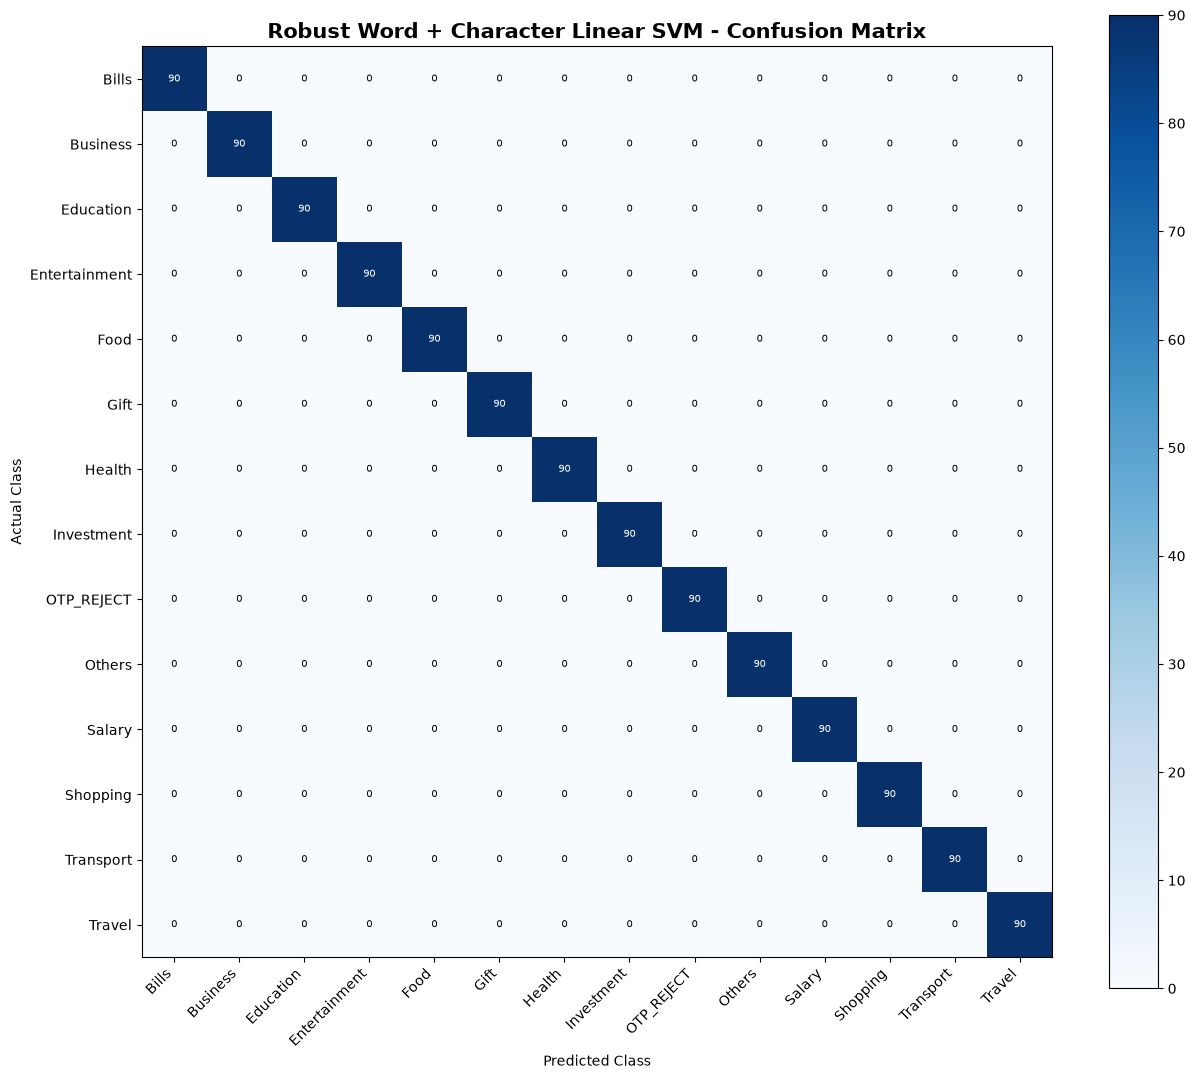

In [20]:
# ============================================================
# STEP 19 - CONFUSION MATRIX
# ============================================================

labels = sorted(
    test_df["Category"].unique()
)

cm = confusion_matrix(

    test_df["Category"],

    robust_test_pred,

    labels=labels
)

plt.figure(
    figsize=(13, 11)
)

plt.imshow(
    cm,
    cmap="Blues"
)

plt.title(
    "Robust Word + Character Linear SVM - Confusion Matrix",
    fontsize=15,
    fontweight="bold"
)

plt.xticks(
    range(len(labels)),
    labels,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(labels)),
    labels
)

plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "Actual Class"
)

threshold = cm.max() / 2

for i in range(len(labels)):

    for j in range(len(labels)):

        plt.text(

            j,
            i,

            cm[i, j],

            ha="center",
            va="center",

            fontsize=7,

            color=(
                "white"
                if cm[i, j] > threshold
                else "black"
            )
        )

plt.colorbar()

plt.tight_layout()

path = (
    ROBUST_FIGURE_DIR
    / "robust_word_char_confusion_matrix.png"
)

plt.savefig(
    path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [21]:
# ============================================================
# STEP 20 - SAVE ROBUST MODEL
# ============================================================

ROBUST_MODEL_PATH = (

    ROBUST_MODEL_DIR
    / "robust_word_character_linear_svm.joblib"
)

joblib.dump(
    robust_model,
    ROBUST_MODEL_PATH
)

print("=" * 70)
print("ROBUST MODEL SAVED")
print("=" * 70)

print(
    ROBUST_MODEL_PATH
)

ROBUST MODEL SAVED
C:\Users\LENOVO\Desktop\Classification_Model\robust_models\robust_word_character_linear_svm.joblib


In [22]:
# ============================================================
# STEP 21 - SAVE RESULTS
# ============================================================

stress_df.to_csv(

    ROBUST_REPORT_DIR
    / "word_char_freeform_stress_test.csv",

    index=False
)


report_df = (
    pd.DataFrame(
        robust_report
    )
    .transpose()
)

report_df.to_csv(

    ROBUST_REPORT_DIR
    / "word_char_classification_report.csv"
)


comparison_df.to_csv(

    ROBUST_REPORT_DIR
    / "old_vs_word_char_svm.csv",

    index=False
)


print(
    "Reports saved."
)

Reports saved.


In [23]:
# ============================================================
# STEP 22 - EXPORT ROBUST MODEL FOR ANDROID
# WORD TF-IDF + CHARACTER TF-IDF + LINEAR SVM
# ============================================================

import json
import numpy as np

print("=" * 70)
print("ROBUST ANDROID MODEL EXPORT")
print("=" * 70)


# ------------------------------------------------------------
# GET MODEL COMPONENTS
# ------------------------------------------------------------

feature_union = (
    robust_model.named_steps[
        "features"
    ]
)

svm = (
    robust_model.named_steps[
        "classifier"
    ]
)


word_tfidf = dict(
    feature_union.transformer_list
)["word_tfidf"]

char_tfidf = dict(
    feature_union.transformer_list
)["char_tfidf"]


# ------------------------------------------------------------
# FEATURE COUNTS
# ------------------------------------------------------------

word_feature_count = len(
    word_tfidf.vocabulary_
)

char_feature_count = len(
    char_tfidf.vocabulary_
)

total_feature_count = (
    word_feature_count
    +
    char_feature_count
)


# ------------------------------------------------------------
# BUILD JSON STRUCTURE
# ------------------------------------------------------------

android_model = {

    "model_name":
        "Robust Word Character Linear SVM",

    "model_version":
        "2.0",

    "classes":
        [
            str(x)
            for x in svm.classes_
        ],

    # --------------------------------------------------------
    # WORD TF-IDF
    # --------------------------------------------------------

    "word_tfidf": {

        "vocabulary": {

            str(word): int(index)

            for word, index
            in word_tfidf.vocabulary_.items()
        },

        "idf": [

            float(x)

            for x in word_tfidf.idf_
        ],

        "ngram_range": [
            int(word_tfidf.ngram_range[0]),
            int(word_tfidf.ngram_range[1])
        ],

        "analyzer":
            str(word_tfidf.analyzer),

        "sublinear_tf":
            bool(word_tfidf.sublinear_tf),

        "norm":
            str(word_tfidf.norm),

        "feature_count":
            word_feature_count
    },


    # --------------------------------------------------------
    # CHARACTER TF-IDF
    # --------------------------------------------------------

    "char_tfidf": {

        "vocabulary": {

            str(token): int(index)

            for token, index
            in char_tfidf.vocabulary_.items()
        },

        "idf": [

            float(x)

            for x in char_tfidf.idf_
        ],

        "ngram_range": [
            int(char_tfidf.ngram_range[0]),
            int(char_tfidf.ngram_range[1])
        ],

        "analyzer":
            str(char_tfidf.analyzer),

        "sublinear_tf":
            bool(char_tfidf.sublinear_tf),

        "norm":
            str(char_tfidf.norm),

        "feature_count":
            char_feature_count
    },


    # --------------------------------------------------------
    # LINEAR SVM
    # --------------------------------------------------------

    "svm": {

        "coefficients": [

            [
                float(value)
                for value in row
            ]

            for row in svm.coef_
        ],

        "intercepts": [

            float(x)

            for x in svm.intercept_
        ],

        "class_count":
            len(svm.classes_),

        "total_feature_count":
            total_feature_count,

        "word_feature_offset":
            0,

        "char_feature_offset":
            word_feature_count
    },


    # --------------------------------------------------------
    # SPECIAL CLASS
    # --------------------------------------------------------

    "special_class":
        "OTP_REJECT",


    # --------------------------------------------------------
    # PREPROCESSING INFORMATION
    # --------------------------------------------------------

    "preprocessing": {

        "lowercase":
            True,

        "amount_token":
            "<AMOUNT>",

        "date_token":
            "<DATE>",

        "time_token":
            "<TIME>",

        "account_token":
            "<ACCOUNT>",

        "reference_token":
            "<REFERENCE>"
    }
}


# ------------------------------------------------------------
# SAVE JSON
# ------------------------------------------------------------

ROBUST_ANDROID_JSON_PATH = (

    ROBUST_MODEL_DIR
    /
    "robust_expense_category_android_model.json"
)


with open(
    ROBUST_ANDROID_JSON_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        android_model,
        f,
        ensure_ascii=False
    )


print("\nExport successful.")

print("\nJSON:")
print(
    ROBUST_ANDROID_JSON_PATH
)

print("\nClasses:")
print(
    len(android_model["classes"])
)

print("\nWord features:")
print(
    word_feature_count
)

print("\nCharacter features:")
print(
    char_feature_count
)

print("\nTotal features:")
print(
    total_feature_count
)

print("\nSVM coefficient matrix:")
print(
    len(svm.coef_),
    "x",
    svm.coef_.shape[1]
)

print("\nSpecial class:")
print(
    android_model["special_class"]
)

print("\n" + "=" * 70)
print("ROBUST ANDROID JSON READY")
print("=" * 70)

ROBUST ANDROID MODEL EXPORT

Export successful.

JSON:
C:\Users\LENOVO\Desktop\Classification_Model\robust_models\robust_expense_category_android_model.json

Classes:
14

Word features:
533

Character features:
6978

Total features:
7511

SVM coefficient matrix:
14 x 7511

Special class:
OTP_REJECT

ROBUST ANDROID JSON READY


In [24]:
# ============================================================
# STEP 23 - VERIFY ROBUST ANDROID JSON
# ============================================================

print("=" * 70)
print("ROBUST ANDROID JSON VERIFICATION")
print("=" * 70)


with open(
    ROBUST_ANDROID_JSON_PATH,
    "r",
    encoding="utf-8"
) as f:

    loaded_json = json.load(f)


word_count = (
    loaded_json[
        "word_tfidf"
    ][
        "feature_count"
    ]
)

char_count = (
    loaded_json[
        "char_tfidf"
    ][
        "feature_count"
    ]
)

total_count = (
    loaded_json[
        "svm"
    ][
        "total_feature_count"
    ]
)


print("\nModel:")
print(
    loaded_json["model_name"]
)

print("\nNumber of classes:")
print(
    len(
        loaded_json["classes"]
    )
)

print("\nWord features:")
print(word_count)

print("\nCharacter features:")
print(char_count)

print("\nTotal features:")
print(total_count)

print("\nCoefficient rows:")
print(
    len(
        loaded_json[
            "svm"
        ][
            "coefficients"
        ]
    )
)

print("\nCoefficient columns:")
print(
    len(
        loaded_json[
            "svm"
        ][
            "coefficients"
        ][0]
    )
)

print("\nIntercepts:")
print(
    len(
        loaded_json[
            "svm"
        ][
            "intercepts"
        ]
    )
)

print("\nSpecial class:")
print(
    loaded_json[
        "special_class"
    ]
)


# ------------------------------------------------------------
# CONSISTENCY CHECK
# ------------------------------------------------------------

assert (
    word_count
    +
    char_count
    ==
    total_count
)

assert (
    len(
        loaded_json[
            "svm"
        ][
            "coefficients"
        ][0]
    )
    ==
    total_count
)

assert (
    len(
        loaded_json[
            "classes"
        ]
    )
    ==
    len(
        loaded_json[
            "svm"
        ][
            "intercepts"
        ]
    )
)


print("\n" + "=" * 70)
print("ROBUST JSON STRUCTURE VERIFIED")
print("=" * 70)

ROBUST ANDROID JSON VERIFICATION

Model:
Robust Word Character Linear SVM

Number of classes:
14

Word features:
533

Character features:
6978

Total features:
7511

Coefficient rows:
14

Coefficient columns:
7511

Intercepts:
14

Special class:
OTP_REJECT

ROBUST JSON STRUCTURE VERIFIED


In [25]:
# ============================================================
# STEP 24 - FINAL ROBUST PROJECT FILE CHECK
# ============================================================

print("=" * 70)
print("FINAL ROBUST MODEL FILE CHECK")
print("=" * 70)


print("\nROBUST MODELS:")

for file in sorted(
    ROBUST_MODEL_DIR.glob("*")
):

    print(
        "OK ",
        file.name
    )


print("\nROBUST REPORTS:")

for file in sorted(
    ROBUST_REPORT_DIR.glob("*")
):

    print(
        "OK ",
        file.name
    )


print("\nROBUST FIGURES:")

for file in sorted(
    ROBUST_FIGURE_DIR.glob("*")
):

    print(
        "OK ",
        file.name
    )


print("\nExpected important files:")

important_files = [

    ROBUST_MODEL_DIR
    / "robust_word_character_linear_svm.joblib",

    ROBUST_MODEL_DIR
    / "robust_expense_category_android_model.json"
]


for file in important_files:

    print(
        "OK" if file.exists() else "MISSING",
        file.name
    )


print("\n" + "=" * 70)
print("ROBUST MODEL PACKAGE COMPLETE")
print("=" * 70)

FINAL ROBUST MODEL FILE CHECK

ROBUST MODELS:
OK  robust_expense_category_android_model.json
OK  robust_word_character_linear_svm.joblib

ROBUST REPORTS:
OK  old_vs_word_char_svm.csv
OK  word_char_classification_report.csv
OK  word_char_freeform_stress_test.csv

ROBUST FIGURES:
OK  robust_word_char_confusion_matrix.png

Expected important files:
OK robust_word_character_linear_svm.joblib
OK robust_expense_category_android_model.json

ROBUST MODEL PACKAGE COMPLETE


In [33]:
# ============================================================
# STEP 25 - FINAL UNSEEN CHALLENGE DATASET
# 14 CLASSES × 10 MESSAGES = 140
# ============================================================

unseen_samples = [

    # ========================================================
    # 1. BILLS
    # ========================================================

    ("Home fibre connection payment of Rs 3180 completed", "Bills"),
    ("Paid LKR 7420 for this month's electricity usage", "Bills"),
    ("Mobile postpaid account settled for Rs 1860", "Bills"),
    ("Water supply charge of LKR 975 was paid online", "Bills"),
    ("Rs 2290 deducted for monthly television subscription", "Bills"),
    ("Internet package renewal cost me LKR 3490", "Bills"),
    ("Paid the household power invoice Rs 6830", "Bills"),
    ("Monthly phone connection charge LKR 1575 settled", "Bills"),
    ("Utility payment of Rs 4120 completed through banking app", "Bills"),
    ("Broadband service fee LKR 2890 paid this morning", "Bills"),


    # ========================================================
    # 2. BUSINESS
    # ========================================================

    ("Customer transferred Rs 47500 for completed design work", "Business"),
    ("Received LKR 63500 against my consulting invoice", "Business"),
    ("Client payment of Rs 28400 arrived for website project", "Business"),
    ("Freelance work payment LKR 19500 credited today", "Business"),
    ("Business customer sent Rs 52200 for supplied services", "Business"),
    ("Received project settlement of LKR 71000 from client", "Business"),
    ("Commercial service payment Rs 36800 received", "Business"),
    ("Customer cleared outstanding invoice with LKR 44500", "Business"),
    ("Rs 21500 received for freelance development work", "Business"),
    ("Client deposited LKR 58000 for completed contract", "Business"),


    # ========================================================
    # 3. EDUCATION
    # ========================================================

    ("Paid Rs 7200 for professional training course", "Education"),
    ("University semester fee LKR 24500 settled", "Education"),
    ("Exam registration charge of Rs 3850 paid", "Education"),
    ("Tuition class payment LKR 5500 completed", "Education"),
    ("Paid Rs 8900 for language course enrollment", "Education"),
    ("School term fee of LKR 13200 was paid", "Education"),
    ("Certification exam payment Rs 4750 completed", "Education"),
    ("Training institute charged LKR 9600 for the course", "Education"),
    ("Paid Rs 18000 for diploma registration", "Education"),
    ("Evening class fee LKR 4200 paid today", "Education"),


    # ========================================================
    # 4. ENTERTAINMENT
    # ========================================================

    ("Spent Rs 2400 on cinema tickets for tonight", "Entertainment"),
    ("Monthly music streaming fee LKR 1150 deducted", "Entertainment"),
    ("Paid Rs 3600 for a gaming subscription", "Entertainment"),
    ("Concert entrance ticket cost LKR 4850", "Entertainment"),
    ("Movie streaming membership Rs 2950 renewed", "Entertainment"),
    ("Paid LKR 1800 for theatre tickets", "Entertainment"),
    ("Online game purchase of Rs 2250 completed", "Entertainment"),
    ("Entertainment subscription charged LKR 1350", "Entertainment"),
    ("Rs 3200 spent on weekend movie tickets", "Entertainment"),
    ("Premium streaming package LKR 2750 renewed", "Entertainment"),


    # ========================================================
    # 5. FOOD
    # ========================================================

    ("Lunch at River Cafe cost Rs 1340", "Food"),
    ("Paid LKR 2850 for dinner at Spice Garden", "Food"),
    ("Breakfast purchase Rs 690 at Morning Kitchen", "Food"),
    ("Coffee and sandwich cost me LKR 920", "Food"),
    ("Restaurant charged Rs 3460 for family dinner", "Food"),
    ("Food order of LKR 1780 was paid online", "Food"),
    ("Bought snacks and drinks for Rs 780", "Food"),
    ("Dinner bill LKR 4250 settled at Ocean Kitchen", "Food"),
    ("Paid Rs 1250 at a local cafe for lunch", "Food"),
    ("Bakery purchase of LKR 640 completed", "Food"),


    # ========================================================
    # 6. GIFT
    # ========================================================

    ("Cousin sent me Rs 6500 as a birthday present", "Gift"),
    ("Received LKR 9000 as a graduation gift", "Gift"),
    ("Friend transferred Rs 3500 as a wedding gift", "Gift"),
    ("Family member sent LKR 12500 as a present", "Gift"),
    ("Rs 4800 received as anniversary gift money", "Gift"),
    ("Received a festival gift of LKR 7200", "Gift"),
    ("Brother transferred Rs 5500 as birthday gift", "Gift"),
    ("LKR 10000 received as housewarming present", "Gift"),
    ("Friend sent gift money Rs 2800", "Gift"),
    ("Received LKR 8500 from family as a gift", "Gift"),


    # ========================================================
    # 7. HEALTH
    # ========================================================

    ("Paid Rs 1280 at Green Care Medicals", "Health"),
    ("Doctor consultation cost LKR 2750", "Health"),
    ("Bought prescribed medicine for Rs 1650", "Health"),
    ("Dental clinic charged LKR 4900 for treatment", "Health"),
    ("Blood test payment Rs 3400 at diagnostic centre", "Health"),
    ("Paid LKR 890 at neighbourhood pharmacy", "Health"),
    ("Hospital consultation fee Rs 3100 settled", "Health"),
    ("Medical laboratory test cost LKR 5250", "Health"),
    ("Pharmcy purchase Rs 1150 completed", "Health"),
    ("Paid LKR 6800 for dental treatment", "Health"),


    # ========================================================
    # 8. INVESTMENT
    # ========================================================

    ("Quarterly investment dividend LKR 8750 received", "Investment"),
    ("Fixed deposit interest of Rs 4650 credited", "Investment"),
    ("Received LKR 11200 from investment returns", "Investment"),
    ("Share portfolio dividend Rs 7300 credited", "Investment"),
    ("Bond interest payment LKR 3950 received", "Investment"),
    ("Investment account credited Rs 9800 as return", "Investment"),
    ("Received LKR 6100 as fund distribution", "Investment"),
    ("Rs 14200 credited from investment portfolio", "Investment"),
    ("Deposit interest LKR 5200 added to account", "Investment"),
    ("Received Rs 8300 as quarterly dividend", "Investment"),


    # ========================================================
    # 9. OTHERS
    # ========================================================

    ("Withdrew Rs 4500 from cash machine near office", "Others"),
    ("Transferred LKR 3800 between my own accounts", "Others"),
    ("Cash deposit of Rs 9200 completed", "Others"),
    ("General bank transfer LKR 5700 processed", "Others"),
    ("Rs 2600 moved to another personal account", "Others"),
    ("Cash withdrawal LKR 7500 completed", "Others"),
    ("Personal transfer of Rs 4300 was processed", "Others"),
    ("Deposited LKR 11800 cash into account", "Others"),
    ("Bank transfer debit Rs 3200 completed", "Others"),
    ("Account transfer of LKR 6900 successful", "Others"),


    # ========================================================
    # 10. SALARY
    # ========================================================

    ("Employer credited my monthly pay of Rs 108000", "Salary"),
    ("LKR 93500 received as this month's salary", "Salary"),
    ("Payroll deposit of Rs 126000 reached my account", "Salary"),
    ("Monthly wages LKR 81500 credited today", "Salary"),
    ("Salary payment Rs 99000 received from employer", "Salary"),
    ("Company payroll credited LKR 117500", "Salary"),
    ("Received Rs 76500 as monthly wage", "Salary"),
    ("Employer salary transfer LKR 104000 completed", "Salary"),
    ("Monthly employee payment Rs 89500 credited", "Salary"),
    ("Payroll credit of LKR 132000 received", "Salary"),


    # ========================================================
    # 11. SHOPPING
    # ========================================================

    ("Spent Rs 875 at Paper Tree stationery store", "Shopping"),
    ("Bought notebooks and pens for LKR 1260", "Shopping"),
    ("Paid Rs 5600 for a new backpack", "Shopping"),
    ("Clothing purchase LKR 7850 at Urban Wear", "Shopping"),
    ("Bought headphones for Rs 13400 at electronics shop", "Shopping"),
    ("Stationary shop purchase cost me LKR 940", "Shopping"),
    ("Paid Rs 2350 for office supplies", "Shopping"),
    ("New shoes cost LKR 6900 at fashion outlet", "Shopping"),
    ("Bought household items for Rs 4150", "Shopping"),
    ("Bookshop purchase LKR 1850 completed", "Shopping"),


    # ========================================================
    # 12. TRANSPORT
    # ========================================================

    ("Taxi ride across town cost Rs 1450", "Transport"),
    ("Filled petrol for LKR 7350", "Transport"),
    ("Morning train fare Rs 520 paid", "Transport"),
    ("Parking charge of LKR 400 settled", "Transport"),
    ("Expressway toll Rs 650 paid", "Transport"),
    ("Cab journey cost LKR 1850", "Transport"),
    ("Fuel purchase Rs 8200 at filling station", "Transport"),
    ("Bus ticket LKR 310 purchased", "Transport"),
    ("Paid Rs 950 for local ride service", "Transport"),
    ("Vehicle parking fee LKR 550 paid", "Transport"),


    # ========================================================
    # 13. TRAVEL
    # ========================================================

    ("Paid Rs 28500 for three nights at guesthouse", "Travel"),
    ("Flight booking LKR 62400 confirmed", "Travel"),
    ("Beach resort reservation cost Rs 19500", "Travel"),
    ("Airport hotel charged LKR 11200 for one night", "Travel"),
    ("Holiday accommodation payment Rs 34800 completed", "Travel"),
    ("Airline ticket purchased for LKR 57800", "Travel"),
    ("Paid Rs 16800 for weekend hotel stay", "Travel"),
    ("Travel agency booking LKR 43500 completed", "Travel"),
    ("Guest house reservation Rs 9200 confirmed", "Travel"),
    ("Paid LKR 26500 for holiday resort booking", "Travel"),


    # ========================================================
    # 14. OTP_REJECT
    # ========================================================

    ("Security code 614827 is required to approve sign in", "OTP_REJECT"),
    ("Use verification PIN 305194 to confirm this device", "OTP_REJECT"),
    ("Your one time login code is 852417 keep it private", "OTP_REJECT"),
    ("Authentication number 416983 expires in three minutes", "OTP_REJECT"),
    ("Enter code 739218 to verify banking access", "OTP_REJECT"),
    ("Do not share security password 581406 with anyone", "OTP_REJECT"),
    ("Verification number 924731 requested for account login", "OTP_REJECT"),
    ("Use code 268415 to authorize this online action", "OTP_REJECT"),
    ("Temporary security PIN 743920 expires shortly", "OTP_REJECT"),
    ("Banking verification code 519638 keep confidential", "OTP_REJECT")
]


unseen_df = pd.DataFrame(
    unseen_samples,
    columns=[
        "SMS",
        "Expected"
    ]
)


print("=" * 70)
print("FINAL UNSEEN CHALLENGE SET CREATED")
print("=" * 70)

print("\nTotal messages:")
print(len(unseen_df))

print("\nMessages per category:")
print(
    unseen_df[
        "Expected"
    ]
    .value_counts()
    .sort_index()
)

FINAL UNSEEN CHALLENGE SET CREATED

Total messages:
140

Messages per category:
Expected
Bills            10
Business         10
Education        10
Entertainment    10
Food             10
Gift             10
Health           10
Investment       10
OTP_REJECT       10
Others           10
Salary           10
Shopping         10
Transport        10
Travel           10
Name: count, dtype: int64


In [34]:
# ============================================================
# STEP 26 - FINAL UNSEEN CHALLENGE EVALUATION
# ============================================================

import re


def normalize_unseen_sms(text):

    text = str(text).lower()

    text = re.sub(
        r'\b(?:lkr|rs\.?|rs)\s*[\d,]+(?:\.\d+)?',
        ' <AMOUNT> ',
        text,
        flags=re.IGNORECASE
    )

    text = re.sub(
        r'\b\d[\d,]*\.\d{1,2}\b',
        ' <AMOUNT> ',
        text
    )

    text = re.sub(
        r'\b\d{4}-\d{1,2}-\d{1,2}\b',
        ' <DATE> ',
        text
    )

    text = re.sub(
        r'\b\d{1,2}[/-]\d{1,2}[/-]\d{2,4}\b',
        ' <DATE> ',
        text
    )

    text = re.sub(
        r'\b\d{1,2}:\d{2}(?::\d{2})?\b',
        ' <TIME> ',
        text
    )

    text = re.sub(
        r'(?:x|\*){3,}\d*',
        ' <ACCOUNT> ',
        text,
        flags=re.IGNORECASE
    )

    text = re.sub(
        r'\b\d{6,}\b',
        ' <REFERENCE> ',
        text
    )

    text = re.sub(
        r'\s+',
        ' ',
        text
    ).strip()

    return text


unseen_df["Clean_SMS"] = (
    unseen_df[
        "SMS"
    ]
    .apply(
        normalize_unseen_sms
    )
)


unseen_df["Prediction"] = (
    robust_model.predict(
        unseen_df[
            "Clean_SMS"
        ]
    )
)


unseen_df["Correct"] = (
    unseen_df[
        "Expected"
    ]
    ==
    unseen_df[
        "Prediction"
    ]
)


unseen_accuracy = (
    unseen_df[
        "Correct"
    ]
    .mean()
)


print("=" * 70)
print("FINAL 140-MESSAGE UNSEEN CHALLENGE")
print("=" * 70)

print(
    "\nAccuracy:",
    f"{unseen_accuracy * 100:.2f}%"
)

print(
    "\nCorrect:",
    unseen_df["Correct"].sum(),
    "/",
    len(unseen_df)
)

print(
    "\nIncorrect:",
    (~unseen_df["Correct"]).sum()
)

FINAL 140-MESSAGE UNSEEN CHALLENGE

Accuracy: 94.29%

Correct: 132 / 140

Incorrect: 8


In [35]:
# ============================================================
# STEP 27 - UNSEEN CLASSIFICATION REPORT
# ============================================================

unseen_report = classification_report(

    unseen_df[
        "Expected"
    ],

    unseen_df[
        "Prediction"
    ],

    output_dict=True,

    zero_division=0
)


unseen_report_df = (
    pd.DataFrame(
        unseen_report
    )
    .transpose()
)


display(
    unseen_report_df.round(4)
)

,precision,recall,f1-score,support
Bills,1.0000,0.7000,0.8235,10.0000
Business,1.0000,1.0000,1.0000,10.0000
Education,1.0000,0.9000,0.9474,10.0000
Entertainment,1.0000,1.0000,1.0000,10.0000
Food,0.8333,1.0000,0.9091,10.0000
Gift,0.8333,1.0000,0.9091,10.0000
Health,1.0000,1.0000,1.0000,10.0000
Investment,1.0000,1.0000,1.0000,10.0000
OTP_REJECT,1.0000,1.0000,1.0000,10.0000
Others,1.0000,0.8000,0.8889,10.0000


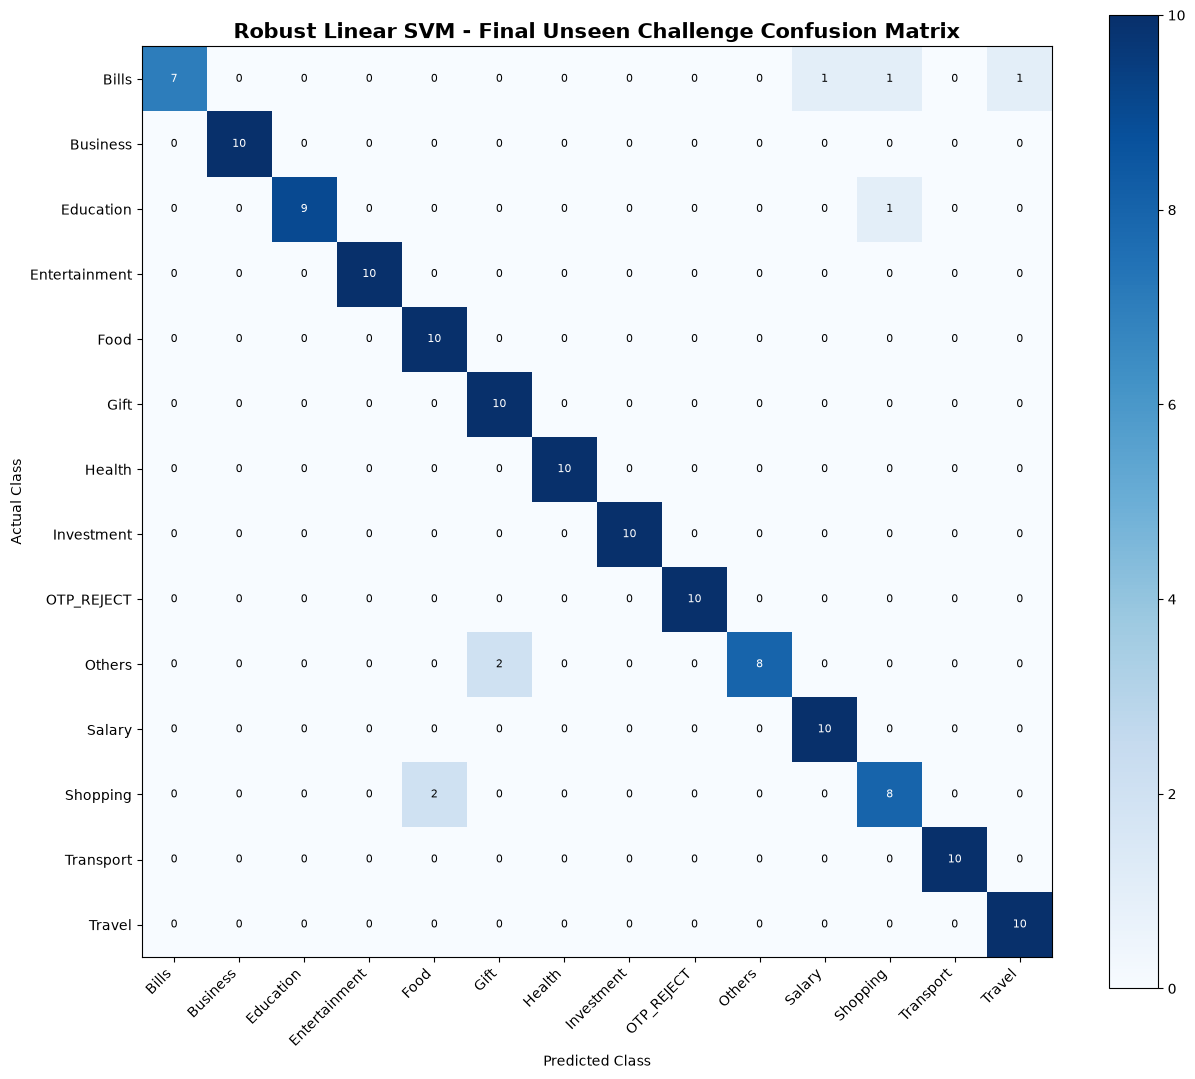

In [36]:
# ============================================================
# STEP 28 - FINAL UNSEEN CONFUSION MATRIX
# ============================================================

labels = sorted(
    unseen_df[
        "Expected"
    ].unique()
)


unseen_cm = confusion_matrix(

    unseen_df[
        "Expected"
    ],

    unseen_df[
        "Prediction"
    ],

    labels=labels
)


plt.figure(
    figsize=(13, 11)
)

plt.imshow(
    unseen_cm,
    cmap="Blues"
)

plt.title(
    "Robust Linear SVM - Final Unseen Challenge Confusion Matrix",
    fontsize=15,
    fontweight="bold"
)

plt.xticks(
    range(len(labels)),
    labels,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(labels)),
    labels
)

plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "Actual Class"
)


threshold = (
    unseen_cm.max()
    / 2
)


for i in range(len(labels)):

    for j in range(len(labels)):

        plt.text(
            j,
            i,
            unseen_cm[i, j],
            ha="center",
            va="center",
            fontsize=8,
            color=(
                "white"
                if unseen_cm[i, j] > threshold
                else "black"
            )
        )


plt.colorbar()

plt.tight_layout()


UNSEEN_CM_PATH = (
    ROBUST_FIGURE_DIR
    / "final_140_unseen_confusion_matrix.png"
)


plt.savefig(
    UNSEEN_CM_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [37]:
# ============================================================
# STEP 29 - CATEGORY-WISE UNSEEN PERFORMANCE
# ============================================================

category_unseen = (

    unseen_df

    .groupby(
        "Expected"
    )

    .agg(

        Total=(
            "Expected",
            "size"
        ),

        Correct=(
            "Correct",
            "sum"
        )
    )
)


category_unseen[
    "Incorrect"
] = (

    category_unseen[
        "Total"
    ]
    -
    category_unseen[
        "Correct"
    ]
)


category_unseen[
    "Accuracy_%"
] = (

    category_unseen[
        "Correct"
    ]

    /

    category_unseen[
        "Total"
    ]

    * 100
)


display(
    category_unseen.round(2)
)

,Total,Correct,Incorrect,Accuracy_%
Expected,,,,
Bills,10,7,3,70.0
Business,10,10,0,100.0
Education,10,9,1,90.0
Entertainment,10,10,0,100.0
Food,10,10,0,100.0
Gift,10,10,0,100.0
Health,10,10,0,100.0
Investment,10,10,0,100.0
OTP_REJECT,10,10,0,100.0


In [38]:
# ============================================================
# STEP 30 - UNSEEN ERROR ANALYSIS
# ============================================================

wrong_unseen = (

    unseen_df[
        unseen_df[
            "Correct"
        ] == False
    ]

    .copy()
)


print("=" * 70)
print("FINAL UNSEEN ERROR ANALYSIS")
print("=" * 70)

print(
    "\nTotal errors:",
    len(wrong_unseen)
)


if len(wrong_unseen) == 0:

    print(
        "\nNo classification errors "
        "were observed in the 140-message challenge set."
    )

else:

    display(

        wrong_unseen[
            [
                "SMS",
                "Expected",
                "Prediction"
            ]
        ]
    )

FINAL UNSEEN ERROR ANALYSIS

Total errors: 8


,SMS,Expected,Prediction
0,Home fibre connection payment of Rs 3180 compl...,Bills,Travel
4,Rs 2290 deducted for monthly television subscr...,Bills,Salary
6,Paid the household power invoice Rs 6830,Bills,Shopping
28,Paid Rs 18000 for diploma registration,Education,Shopping
84,Rs 2600 moved to another personal account,Others,Gift
86,Personal transfer of Rs 4300 was processed,Others,Gift
101,Bought notebooks and pens for LKR 1260,Shopping,Food
102,Paid Rs 5600 for a new backpack,Shopping,Food


In [39]:
# ============================================================
# STEP 31 - SAVE FINAL UNSEEN RESULTS
# ============================================================

UNSEEN_RESULT_PATH = (

    ROBUST_REPORT_DIR
    / "final_140_unseen_challenge_results.csv"
)


unseen_df.to_csv(
    UNSEEN_RESULT_PATH,
    index=False
)


UNSEEN_REPORT_PATH = (

    ROBUST_REPORT_DIR
    / "final_140_unseen_classification_report.csv"
)


unseen_report_df.to_csv(
    UNSEEN_REPORT_PATH
)


print("=" * 70)
print("FINAL UNSEEN RESULTS SAVED")
print("=" * 70)

print(
    "\nResults:",
    UNSEEN_RESULT_PATH
)

print(
    "\nReport:",
    UNSEEN_REPORT_PATH
)

print(
    "\nConfusion Matrix:",
    UNSEEN_CM_PATH
)

FINAL UNSEEN RESULTS SAVED

Results: C:\Users\LENOVO\Desktop\Classification_Model\robust_reports\final_140_unseen_challenge_results.csv

Report: C:\Users\LENOVO\Desktop\Classification_Model\robust_reports\final_140_unseen_classification_report.csv

Confusion Matrix: C:\Users\LENOVO\Desktop\Classification_Model\robust_figures\final_140_unseen_confusion_matrix.png


In [40]:
# ============================================================
# STEP 25 - RESTART-SAFE ROBUST MODEL LOADER
# ============================================================

import re
import joblib

from pathlib import Path


BASE_DIR = (
    Path.home()
    / "Desktop"
    / "Classification_Model"
)

ROBUST_MODEL_PATH = (

    BASE_DIR
    / "robust_models"
    / "robust_word_character_linear_svm.joblib"
)


# ------------------------------------------------------------
# LOAD FINAL ROBUST MODEL
# ------------------------------------------------------------

robust_live_model = (
    joblib.load(
        ROBUST_MODEL_PATH
    )
)


# ------------------------------------------------------------
# SAME NORMALIZATION USED DURING TRAINING
# ------------------------------------------------------------

def normalize_live_sms(text):

    text = str(text).lower()


    # Currency amounts
    text = re.sub(

        r'\b(?:lkr|rs\.?|rs)\s*[\d,]+(?:\.\d+)?',

        ' <AMOUNT> ',

        text,

        flags=re.IGNORECASE
    )


    # Decimal amounts
    text = re.sub(

        r'\b\d[\d,]*\.\d{1,2}\b',

        ' <AMOUNT> ',

        text
    )


    # Dates
    text = re.sub(

        r'\b\d{4}-\d{1,2}-\d{1,2}\b',

        ' <DATE> ',

        text
    )


    text = re.sub(

        r'\b\d{1,2}[/-]\d{1,2}[/-]\d{2,4}\b',

        ' <DATE> ',

        text
    )


    # Time
    text = re.sub(

        r'\b\d{1,2}:\d{2}(?::\d{2})?\b',

        ' <TIME> ',

        text
    )


    # Masked account
    text = re.sub(

        r'(?:x|\*){3,}\d*',

        ' <ACCOUNT> ',

        text,

        flags=re.IGNORECASE
    )


    # OTP / reference
    text = re.sub(

        r'\b\d{6,}\b',

        ' <REFERENCE> ',

        text
    )


    # Extra spaces
    text = re.sub(

        r'\s+',

        ' ',

        text
    ).strip()


    return text


# ------------------------------------------------------------
# FINAL CLASSIFICATION FUNCTION
# ------------------------------------------------------------

def classify_robust_sms(sms):

    cleaned_sms = (
        normalize_live_sms(
            sms
        )
    )


    prediction = (

        robust_live_model.predict(
            [cleaned_sms]
        )[0]
    )


    if prediction == "OTP_REJECT":

        return {

            "SMS":
                sms,

            "Clean_SMS":
                cleaned_sms,

            "Prediction":
                "OTP_REJECT",

            "Action":
                "IGNORE - Do not store as expense transaction"
        }


    return {

        "SMS":
            sms,

        "Clean_SMS":
            cleaned_sms,

        "Prediction":
            prediction,

        "Action":
            "VALID TRANSACTION - Can be stored"
    }


print("=" * 70)
print("ROBUST LIVE DEMO ENVIRONMENT READY")
print("=" * 70)

print("\nLoaded model:")
print(
    ROBUST_MODEL_PATH
)


ROBUST LIVE DEMO ENVIRONMENT READY

Loaded model:
C:\Users\LENOVO\Desktop\Classification_Model\robust_models\robust_word_character_linear_svm.joblib


In [57]:
# ============================================================
# STEP 26 - FINAL ROBUST LIVE SMS DEMO
# ============================================================

message = input(
    "Enter transaction SMS: "
)


result = (
    classify_robust_sms(
        message
    )
)


print("\n" + "=" * 70)
print("ROBUST LIVE SMS CLASSIFICATION RESULT")
print("=" * 70)


print("\nInput SMS:")
print(
    result["SMS"]
)


print("\nPredicted Category:")
print(
    result["Prediction"]
)


print("\nSystem Action:")
print(
    result["Action"]
)


print("\n" + "=" * 70)


Enter transaction SMS:  moved rs 2500 to my other bank account



ROBUST LIVE SMS CLASSIFICATION RESULT

Input SMS:
moved rs 2500 to my other bank account

Predicted Category:
Others

System Action:
VALID TRANSACTION - Can be stored

